# Sarcasm Detection

The goal is to classify news headlines as sarcastic or not. The dataset has 26,709 headlines: the sarcastic ones come from the satirical newspaper The Onion and the others from HuffPost (`Sarcasm.json`).

Reference solution: [Sarcasm Detection with Machine Learning](https://amanxai.com/2021/08/24/sarcasm-detection-with-machine-learning/) (Aman Kharwal). Dataset: [Sarcasm.json](https://raw.githubusercontent.com/amankharwal/Website-data/master/Sarcasm.json).

The reference counts the words of each headline (`CountVectorizer`), trains a Bernoulli Naive Bayes on a 80/20 split and reports an accuracy of 0.845. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/NLP/sarcasm_detection')

## Data Loading

In [2]:
data = pd.read_json("Sarcasm.json", lines=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26709 entries, 0 to 26708
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   article_link  26709 non-null  str  
 1   headline      26709 non-null  str  
 2   is_sarcastic  26709 non-null  int64
dtypes: int64(1), str(2)
memory usage: 4.5 MB


## Data Cleaning

There are no null values. 107 headlines appear twice (with the same label), which would put the same headline in the training and in the test set, so the duplicates are removed.

In [3]:
print("duplicated headlines:", data["headline"].duplicated().sum())
data = data.drop_duplicates(subset="headline").reset_index(drop=True)
data.shape

duplicated headlines: 107


(26602, 3)

## What the Label Measures

The dataset also has the link of each article. The website of the link shows where each headline comes from.

In [4]:
data["site"] = data["article_link"].str.extract(r"https?://(?:[a-z]+\.)?([a-z]+\.com)")[0]
pd.crosstab(data["site"], data["is_sarcastic"])

is_sarcastic,0,1
site,,
huffingtonpost.com,14951,0
theonion.com,0,11651


Every headline from `theonion.com` is labelled sarcastic and every headline from `huffingtonpost.com` is not: the label is the newspaper. A model trained on the headlines therefore does not learn what sarcasm is, it learns to tell an Onion headline from a HuffPost headline (topics, formulas such as "area man", capitalisation habits removed by the lower-casing, and so on). The accuracy it reaches says how well the two writing styles can be told apart. The column with the link is not used as a feature: it would give a perfect but meaningless result.

## Exploratory Data Analysis

In [5]:
data["words"] = data["headline"].str.split().str.len()
print(data.groupby("is_sarcastic")["words"].describe().round(1))
print("share of sarcastic headlines:", round(data["is_sarcastic"].mean(), 3))

                count  mean  std  min  25%   50%   75%   max
is_sarcastic                                                
0             14951.0   9.8  2.9  2.0  8.0  10.0  12.0  38.0
1             11651.0   9.9  3.5  2.0  7.0  10.0  12.0  39.0
share of sarcastic headlines: 0.438


The two classes have the same headline length (about 10 words) and are fairly balanced (44% sarcastic), so the length gives no shortcut and accuracy is a usable metric.

## Reference Reproduction

The reference is reproduced on the original data: word counts, Bernoulli Naive Bayes, 20% test set with `random_state=42`. The `score` of a scikit-learn classifier is the accuracy.

In [6]:
raw = pd.read_json("Sarcasm.json", lines=True)
raw_x = CountVectorizer().fit_transform(raw["headline"])
raw_train, raw_test, raw_y_train, raw_y_test = train_test_split(raw_x, raw["is_sarcastic"], test_size=0.20, random_state=42)

print("reference accuracy:", BernoulliNB().fit(raw_train, raw_y_train).score(raw_test, raw_y_test))

reference accuracy: 0.8448146761512542


## Feature Engineering

The cleaned data is split 80/20 and stratified. `CountVectorizer`: single words as in the reference, and single words plus pairs of consecutive words (`ngram_range=(1, 2)`, which is also used in the lesson). Pairs keep a little of the word order, for example "area man" or "white house". Words that appear in fewer than 2 headlines are ignored in the second version (`min_df=2`), otherwise the number of features becomes very large.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(data["headline"], data["is_sarcastic"], test_size=0.2, random_state=42, stratify=data["is_sarcastic"])

unigrams = CountVectorizer().fit(x_train)
bigrams = CountVectorizer(ngram_range=(1, 2), min_df=2).fit(x_train)
print("single words:", len(unigrams.vocabulary_), "| words and pairs:", len(bigrams.vocabulary_))

single words: 22858 | words and pairs: 31285


## Model Training

In [8]:
def make_models():
    return {
        "Bernoulli Naive Bayes": BernoulliNB(),
        "Multinomial Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
    }

vectorizers = {"words": unigrams, "words and pairs": bigrams}

fitted = {(v, m): model.fit(vec.transform(x_train), y_train) for v, vec in vectorizers.items() for m, model in make_models().items()}
predictions = {key: model.predict(vectorizers[key[0]].transform(x_test)) for key, model in fitted.items()}

pd.DataFrame({key: {"Accuracy": accuracy_score(y_test, p), "Precision": precision_score(y_test, p), "Recall": recall_score(y_test, p), "F1": f1_score(y_test, p)}
              for key, p in predictions.items()}).T.round(3)

Accuracy  Precision  Recall     F1
words           Bernoulli Naive Bayes       0.847      0.861   0.776  0.816
                Multinomial Naive Bayes     0.849      0.840   0.809  0.824
                Logistic Regression         0.842      0.823   0.816  0.819
                Decision Tree               0.753      0.715   0.726  0.720
words and pairs Bernoulli Naive Bayes       0.853      0.838   0.823  0.830
                Multinomial Naive Bayes     0.853      0.827   0.839  0.833
                Logistic Regression         0.847      0.824   0.828  0.826
                Decision Tree               0.748      0.709   0.718  0.714

## Evaluation

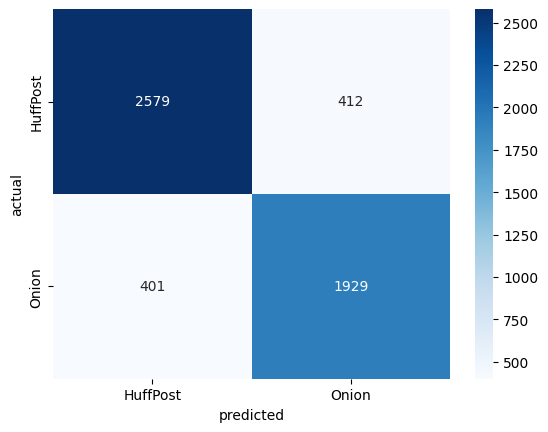

In [9]:
best = ("words and pairs", "Logistic Regression")  # not the highest accuracy, but its coefficients can be read
sns.heatmap(confusion_matrix(y_test, predictions[best]), annot=True, fmt="d", cmap="Blues", xticklabels=["HuffPost", "Onion"], yticklabels=["HuffPost", "Onion"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()

In [10]:
coefficients = pd.Series(fitted[best].coef_[0], index=bigrams.get_feature_names_out()).sort_values()
print("words and pairs that point to HuffPost:", coefficients.head(12).index.tolist())
print("words and pairs that point to The Onion:", coefficients.tail(12).index.tolist()[::-1])

words and pairs that point to HuffPost: ['an', 'the', 'is', 'transgender', 'and', 'california', 'why', 'allegedly', 'trans', 'protest', 'queer', 'watch']
words and pairs that point to The Onion: ['nation', 'area', 'local', 'shit', 'fucking', 'introduces', 'onion', 'clearly', 'guy', 'fuck', 'few', 'wondering']


The strongest signals show what the models learn: they are topics and formulas of each newspaper, not a feature of sarcasm as such. The last test uses headlines written for this notebook: three in the style of a serious news site and three in the style of a satirical one.

In [11]:
examples = ["senate passes bill to fund federal highway projects",
            "study finds link between sleep and heart health",
            "president signs executive order on immigration policy",
            "area man wins argument with wife by staying silent for six hours",
            "nation's cats confirm they have no idea what they are doing",
            "cows lose their jobs as milk prices drop"]
probabilities = fitted[best].predict_proba(bigrams.transform(examples))[:, 1]
pd.DataFrame({"headline": examples, "probability of The Onion": probabilities.round(3)})

,headline,probability of The Onion
0,senate passes bill to fund federal highway pro...,0.203
1,study finds link between sleep and heart health,0.699
2,president signs executive order on immigration...,0.101
3,area man wins argument with wife by staying si...,1.000
4,nation's cats confirm they have no idea what t...,0.997
5,cows lose their jobs as milk prices drop,0.354


The label is the newspaper: after removing 107 duplicated headlines, all 14,951 HuffPost headlines are labelled "not sarcastic" and all 11,651 Onion headlines "sarcastic". The reference accuracy of 0.845 is reproduced exactly (0.8448), and the other models do not change the picture much: Bernoulli and Multinomial Naive Bayes on words and pairs reach 0.853, Logistic Regression 0.847, and the Decision Tree is clearly worse (0.75). Precision and recall of the Onion class are balanced (0.83 and 0.82 to 0.84), so the model does not favour one newspaper. Adding pairs of words gives a gain of about 0.5 points, which is small.

The words with the strongest weights in the Logistic Regression (chosen for the interpretation because its coefficients can be read, not because it has the highest accuracy) are typical of the two newspapers and not of sarcasm. The Onion is recognised by formulas such as "nation", "area", "local", "guy", "introduces" and by strong language, and HuffPost by its topics ("transgender", "queer", "california", "protest") and by function words such as "an", "the", "is" and "and", which reflect how the two newspapers write their headlines.

The examples written for this notebook confirm it. Serious headlines get a low probability of being from the Onion (0.20 and 0.10), but "study finds link between sleep and heart health" gets 0.70 because "study finds" is a formula of the Onion; the two satirical headlines that use the formulas "area man" and "nation's" get 1.00 and 0.997, and the reference example "cows lose their jobs as milk prices drop" gets only 0.35, so it would be classified as not sarcastic, while the reference reports it as sarcasm. A model that recognises a newspaper cannot be expected to recognise sarcasm in other texts.

## Conclusion

**Reference approach.** The reference counts the words of the headlines (`CountVectorizer`), trains a Bernoulli Naive Bayes on an 80/20 split and reports an accuracy of 0.845. It tests the model with one headline typed by hand ("Cows lose their jobs as milk prices drop", predicted as sarcasm).

**What the data measures.** The labels come from the source of the headline: every headline of The Onion is "sarcastic" and every headline of HuffPost is not. The task is therefore to recognise the newspaper, and a model that does it well has learnt the vocabulary and the formulas of each newspaper (Onion: "area man", "nation", "local", "introduces"; HuffPost: political topics and the way its headlines are written), not sarcasm. The reference does not mention this.

**Results** (26,602 headlines after removing 107 duplicates; 20% stratified test set, scores for the Onion class):

| Model | Features | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Bernoulli Naive Bayes (reference) | words | 0.847 | 0.861 | 0.776 | 0.816 |
| Multinomial Naive Bayes | words | 0.849 | 0.840 | 0.809 | 0.824 |
| Logistic Regression | words | 0.842 | 0.823 | 0.816 | 0.819 |
| Decision Tree | words | 0.753 | 0.715 | 0.726 | 0.720 |
| Bernoulli Naive Bayes | words and pairs | 0.853 | 0.838 | 0.823 | 0.830 |
| Multinomial Naive Bayes | words and pairs | 0.853 | 0.827 | 0.839 | 0.833 |
| Logistic Regression | words and pairs | 0.847 | 0.824 | 0.828 | 0.826 |
| Decision Tree | words and pairs | 0.748 | 0.709 | 0.718 | 0.714 |

The Naive Bayes models and Logistic Regression are within one point of each other, and the reference model is as good as the alternatives. Pairs of words help by less than one point. The reference example is classified as not sarcastic by the Logistic Regression (probability 0.35 for the Onion).

**Limitations.** The score measures how well two newspapers can be told apart, so it should not be read as a sarcasm detector. It would fall for other sources of text (tweets, reviews), which use neither the same topics nor the same formulas; this was not tested because there is no second source in the data. Headlines were lower-cased, so capitalisation habits are ignored. Only word counts were used; a model that reads the meaning of the sentence would be needed to detect sarcasm itself.